In [1]:
# BLOCK 1: Extract Dataset
print("Extracting Dataset")
import zipfile
import os
 
zip_path = "Plant_leaf_diseases_dataset_without_augmentation.zip"
extract_path = "./Plant_leaf_diseases_dataset_without_augmentation"
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print("Dataset Extracted!")

Extracting Dataset
Dataset Extracted!


In [2]:
# BLOCK 2: Import Libraries
print("Importing Libraries")
import gc
import pickle
import copy
 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.linear_model import LogisticRegression

# ── Device configuration ────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("  No GPU found — running on CPU (install CUDA-enabled PyTorch for GPU support)")
print("Imports done!")

Importing Libraries
Using device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM: 6.4 GB
Imports done!


In [3]:
# BLOCK 3: Load Dataset
print("Loading Dataset")
extract_path   = './Plant_leaf_diseases_dataset_without_augmentation'
dataset_dir    = os.path.join(extract_path, 'Plant_leave_diseases_dataset_without_augmentation')
 
IMAGE_SIZE  = (192, 192)
BATCH_SIZE  = 32
 
# ImageNet normalisation constants (used by all three pretrained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
# ── Validation transform (no augmentation) ──────────────────
val_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
# ── Determine 80/20 split indices (seed=123 for reproducibility) ─
_reference_dataset = datasets.ImageFolder(root=dataset_dir)
total_size  = len(_reference_dataset)
val_size    = int(0.2 * total_size)
train_size  = total_size - val_size
 
generator      = torch.Generator().manual_seed(123)
all_indices    = torch.randperm(total_size, generator=generator).tolist()
train_indices  = all_indices[:train_size]
val_indices    = all_indices[train_size:]
 
class_names = _reference_dataset.classes
num_classes = len(class_names)
del _reference_dataset   # free memory
 
# ── Create validation loader (no augmentation) ──────────────
val_full    = datasets.ImageFolder(root=dataset_dir, transform=val_transform)
val_dataset = Subset(val_full, val_indices)
val_loader  = DataLoader(
    val_dataset, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=4, pin_memory=True
)
 
print(f"Dataset loaded! {num_classes} classes")
print(f"   Image size : {IMAGE_SIZE}")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   Train size : {train_size}")
print(f"   Val size   : {val_size}")

Loading Dataset
Dataset loaded! 39 classes
   Image size : (192, 192)
   Batch size : 32
   Train size : 44359
   Val size   : 11089


In [4]:
# BLOCK 4: Data Augmentation
print("Setting up Data Augmentation")
# Note: geometric augmentations come BEFORE ToTensor + Normalize in PyTorch
# RandomRotation(0.1) in TF is a fraction of 2π ≈ 36 degrees
# RandomZoom(0.2) in TF ≈ scale crop between 80 %–100 % of the image
train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=36),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])
 
train_full    = datasets.ImageFolder(root=dataset_dir, transform=train_transform)
train_dataset = Subset(train_full, train_indices)
train_loader  = DataLoader(
    train_dataset, batch_size=BATCH_SIZE,
    shuffle=True, num_workers=4, pin_memory=True
)
print(f"Augmentation transforms defined!")
print(f"   Training batches   : {len(train_loader)}")
print(f"   Validation batches : {len(val_loader)}")

Setting up Data Augmentation
Augmentation transforms defined!
   Training batches   : 1387
   Validation batches : 347


In [5]:
# BLOCK 5: Build Model
print("Building Models")
 
def build_model(model_name: str, num_classes: int) -> nn.Module:
    """
    Load an ImageNet-pretrained backbone and attach a custom
    classification head. All backbone weights are frozen here;
    unfreezing happens inside the two-stage training function.
    """
    if model_name == "MobileNetV2":
        backbone = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        # Freeze backbone
        for param in backbone.parameters():
            param.requires_grad = False
        # Replace top classifier
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
 
    elif model_name == "ResNet50":
        backbone = models.resnet50(
            weights=models.ResNet50_Weights.IMAGENET1K_V1
        )
        for param in backbone.parameters():
            param.requires_grad = False
        in_features = backbone.fc.in_features
        backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
 
    elif model_name == "EfficientNetB0":
        backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )
        for param in backbone.parameters():
            param.requires_grad = False
        in_features = backbone.classifier[1].in_features
        backbone.classifier = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
 
    else:
        raise ValueError(f"Unknown model: {model_name}")
 
    return backbone.to(device)
 
 
def get_head_params(model: nn.Module, model_name: str):
    """Return only the classifier-head parameters for Stage-1 optimiser."""
    if model_name == "ResNet50":
        return model.fc.parameters()
    else:                                   # MobileNetV2, EfficientNetB0
        return model.classifier.parameters()
 
 
def set_backbone_trainable(model: nn.Module, model_name: str, trainable: bool):
    """Freeze or unfreeze the feature-extraction backbone."""
    if model_name == "ResNet50":
        # Everything except the fc head
        for name, param in model.named_parameters():
            if "fc" not in name:
                param.requires_grad = trainable
    else:
        # Everything except the classifier head
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = trainable
 
 
print("Model builder ready!")

Building Models
Model builder ready!


In [6]:
# BLOCK 6: Training Function — Two-Stage Transfer Learning
print("Defining Training Function")
 
 
def run_epoch(model, loader, criterion, optimizer=None, train=True):
    """Run a single epoch; if optimizer is None, runs in eval mode."""
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
 
    with torch.set_grad_enabled(train):
        for images, labels in loader:
            images, labels = images.to(device, non_blocking=True), \
                             labels.to(device, non_blocking=True)
 
            if train and optimizer is not None:
                optimizer.zero_grad()
 
            outputs = model(images)
            loss    = criterion(outputs, labels)
 
            if train and optimizer is not None:
                loss.backward()
                optimizer.step()
 
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct      += predicted.eq(labels).sum().item()
            total        += labels.size(0)
 
    return total_loss / total, correct / total
 
 
def train_model_two_stage(model_name, model, train_loader, val_loader):
    print(f'\nTraining {model_name}  (TWO-STAGE TRANSFER LEARNING)')
    criterion = nn.CrossEntropyLoss()
    history   = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}
 
    # ── STAGE 1: Frozen backbone ─────────────────────────────
    print(f'\n[STAGE 1] Training with FROZEN backbone …')
    print( '          Only the dense head is updated — very fast.')
    set_backbone_trainable(model, model_name, trainable=False)
    optimizer = optim.Adam(get_head_params(model, model_name), lr=1e-3)
 
    best_val_loss = float('inf')
    patience_ctr  = 0
    best_weights  = copy.deepcopy(model.state_dict())
 
    for epoch in range(5):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        v_loss, v_acc = run_epoch(model, val_loader,   criterion, train=False)
 
        history['loss'].append(t_loss);         history['accuracy'].append(t_acc)
        history['val_loss'].append(v_loss);     history['val_accuracy'].append(v_acc)
 
        print(f"  Epoch [{epoch+1}/5]  "
              f"Train → Loss: {t_loss:.4f}  Acc: {t_acc*100:.2f}%  |  "
              f"Val → Loss: {v_loss:.4f}  Acc: {v_acc*100:.2f}%")
 
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights  = copy.deepcopy(model.state_dict())
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 2:
                print(f"  Early stopping triggered at epoch {epoch+1}")
                break
 
    model.load_state_dict(best_weights)
    print(f'\nStage 1 Complete!  Val Accuracy: {history["val_accuracy"][-1]*100:.2f}%')
 
    # ── STAGE 2: Fine-tune full model ────────────────────────
    print(f'\n[STAGE 2] Fine-tuning with UNFROZEN backbone …')
    print( '          Full model updated with a very small learning rate.')
    set_backbone_trainable(model, model_name, trainable=True)
    optimizer = optim.Adam(model.parameters(), lr=1e-5)
 
    best_val_loss = float('inf')
    patience_ctr  = 0
    best_weights  = copy.deepcopy(model.state_dict())
 
    for epoch in range(3):
        t_loss, t_acc = run_epoch(model, train_loader, criterion, optimizer, train=True)
        v_loss, v_acc = run_epoch(model, val_loader,   criterion, train=False)
 
        history['loss'].append(t_loss);         history['accuracy'].append(t_acc)
        history['val_loss'].append(v_loss);     history['val_accuracy'].append(v_acc)
 
        print(f"  Epoch [{epoch+1}/3]  "
              f"Train → Loss: {t_loss:.4f}  Acc: {t_acc*100:.2f}%  |  "
              f"Val → Loss: {v_loss:.4f}  Acc: {v_acc*100:.2f}%")
 
        if v_loss < best_val_loss:
            best_val_loss = v_loss
            best_weights  = copy.deepcopy(model.state_dict())
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= 1:
                print(f"  Early stopping triggered at epoch {epoch+1}")
                break
 
    model.load_state_dict(best_weights)
    print(f'\nStage 2 Complete!  Val Accuracy: {history["val_accuracy"][-1]*100:.2f}%')
 
    return model, history
 
 
print("Training function ready!")

Defining Training Function
Training function ready!


In [7]:
# BLOCK 7: Train All Three Models
print("Training All Models")
model_names    = ['MobileNetV2', 'ResNet50', 'EfficientNetB0']
models_dict    = {}
histories_dict = {}
 
for name in model_names:
    print(f'\n\nBuilding and training {name} …')
    model          = build_model(name, num_classes)
    model, history = train_model_two_stage(name, model, train_loader, val_loader)
    models_dict[name]    = model
    histories_dict[name] = history
 
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print(f"\n{name} training complete!\n")

Training All Models


Building and training MobileNetV2 …

Training MobileNetV2  (TWO-STAGE TRANSFER LEARNING)

[STAGE 1] Training with FROZEN backbone …
          Only the dense head is updated — very fast.
  Epoch [1/5]  Train → Loss: 0.6462  Acc: 81.20%  |  Val → Loss: 0.2995  Acc: 90.28%
  Epoch [2/5]  Train → Loss: 0.3621  Acc: 88.53%  |  Val → Loss: 0.2405  Acc: 92.09%
  Epoch [3/5]  Train → Loss: 0.3205  Acc: 89.51%  |  Val → Loss: 0.2811  Acc: 90.69%
  Epoch [4/5]  Train → Loss: 0.3020  Acc: 90.01%  |  Val → Loss: 0.2361  Acc: 92.37%
  Epoch [5/5]  Train → Loss: 0.2844  Acc: 90.64%  |  Val → Loss: 0.2080  Acc: 92.77%

Stage 1 Complete!  Val Accuracy: 92.77%

[STAGE 2] Fine-tuning with UNFROZEN backbone …
          Full model updated with a very small learning rate.
  Epoch [1/3]  Train → Loss: 0.1712  Acc: 94.31%  |  Val → Loss: 0.0896  Acc: 97.08%
  Epoch [2/3]  Train → Loss: 0.1077  Acc: 96.40%  |  Val → Loss: 0.0786  Acc: 97.28%
  Epoch [3/3]  Train → Loss: 0.0911  Acc: 96.9

In [8]:
# BLOCK 8: Get Predictions on Validation Set

y_true = []
for _, labels in val_loader:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)
print(f"Total validation samples: {len(y_true)}")
 
all_predictions  = {}
all_pred_classes = {}
 
for name in model_names:
    print(f"\nGetting predictions from {name} …")
    model = models_dict[name]
    model.eval()
    predictions = []
 
    with torch.no_grad():
        for images, _ in val_loader:
            images  = images.to(device, non_blocking=True)
            outputs = model(images)
            probs   = torch.softmax(outputs, dim=1)
            predictions.append(probs.cpu().numpy())
 
    predictions = np.concatenate(predictions, axis=0)
    all_predictions[name]  = predictions
    all_pred_classes[name] = np.argmax(predictions, axis=1)
    print(f"  Predictions shape: {predictions.shape}")
 
print("\nAll predictions collected!")
 

Total validation samples: 11089

Getting predictions from MobileNetV2 …
  Predictions shape: (11089, 39)

Getting predictions from ResNet50 …
  Predictions shape: (11089, 39)

Getting predictions from EfficientNetB0 …
  Predictions shape: (11089, 39)

All predictions collected!


In [9]:
# BLOCK 9: Individual Model Performance
print("Individual Model Performance")
individual_metrics = []
 
for name in model_names:
    y_pred = all_pred_classes[name]
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score   (y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score       (y_true, y_pred, average='weighted', zero_division=0)
    individual_metrics.append(
        {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}
    )
    print(f"\n{name}:")
    print(f"   Accuracy  : {acc*100:.2f}%")
    print(f"   Precision : {prec*100:.2f}%")
    print(f"   Recall    : {rec*100:.2f}%")
    print(f"   F1 Score  : {f1*100:.2f}%")
 
df_individual = pd.DataFrame(individual_metrics)
print("\nMetrics Summary:")
print(df_individual.to_string(index=False))

Individual Model Performance

MobileNetV2:
   Accuracy  : 98.03%
   Precision : 98.10%
   Recall    : 98.03%
   F1 Score  : 98.04%

ResNet50:
   Accuracy  : 98.83%
   Precision : 98.84%
   Recall    : 98.83%
   F1 Score  : 98.82%

EfficientNetB0:
   Accuracy  : 97.68%
   Precision : 97.73%
   Recall    : 97.68%
   F1 Score  : 97.66%

Metrics Summary:
         Model  Accuracy  Precision   Recall  F1 Score
   MobileNetV2  0.980341   0.981036 0.980341  0.980419
      ResNet50  0.988277   0.988420 0.988277  0.988236
EfficientNetB0  0.976824   0.977254 0.976824  0.976631


In [10]:
# BLOCK 10: Per-Class Performance Report
print("Per-Class Performance Detailed Report")
per_class_reports = {}
 
for name in model_names:
    y_pred = all_pred_classes[name]
    print(f"\n{name} — Classification Report")
    print("-" * 70)
    report = classification_report(
        y_true, y_pred, target_names=class_names, digits=4, output_dict=True
    )
    per_class_reports[name] = report
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Per-Class Performance Detailed Report

MobileNetV2 — Classification Report
----------------------------------------------------------------------
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     0.9845    0.9621    0.9732       132
                            Apple___Black_rot     1.0000    1.0000    1.0000       114
                     Apple___Cedar_apple_rust     1.0000    0.9818    0.9908        55
                              Apple___healthy     0.9938    1.0000    0.9969       323
                    Background_without_leaves     0.9956    1.0000    0.9978       228
                          Blueberry___healthy     0.9906    1.0000    0.9953       317
                      Cherry___Powdery_mildew     1.0000    0.9752    0.9875       202
                             Cherry___healthy     0.9887    0.9887    0.9887       177
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.8088    0.9322    

In [11]:
# BLOCK 11: Ensemble Method 1 — Soft Voting
print("Ensemble Method 1 — Soft Voting")
ensemble_probs_voting = np.mean([
    all_predictions['MobileNetV2'],
    all_predictions['ResNet50'],
    all_predictions['EfficientNetB0'],
], axis=0)
ensemble_pred_voting = np.argmax(ensemble_probs_voting, axis=1)
 
acc_voting  = accuracy_score (y_true, ensemble_pred_voting)
prec_voting = precision_score(y_true, ensemble_pred_voting, average='weighted', zero_division=0)
rec_voting  = recall_score   (y_true, ensemble_pred_voting, average='weighted', zero_division=0)
f1_voting   = f1_score       (y_true, ensemble_pred_voting, average='weighted', zero_division=0)
 
print(f"\nSoft Voting Ensemble Results:")
print(f"   Accuracy  : {acc_voting*100:.2f}%")
print(f"   Precision : {prec_voting*100:.2f}%")
print(f"   Recall    : {rec_voting*100:.2f}%")
print(f"   F1 Score  : {f1_voting*100:.2f}%")
print(f"\nPer-Class Report:")
report_voting = classification_report(
    y_true, ensemble_pred_voting, target_names=class_names, digits=4, output_dict=True
)
print(classification_report(y_true, ensemble_pred_voting, target_names=class_names, digits=4))

Ensemble Method 1 — Soft Voting

Soft Voting Ensemble Results:
   Accuracy  : 99.13%
   Precision : 99.14%
   Recall    : 99.13%
   F1 Score  : 99.13%

Per-Class Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     1.0000    0.9773    0.9885       132
                            Apple___Black_rot     1.0000    1.0000    1.0000       114
                     Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                              Apple___healthy     0.9969    1.0000    0.9985       323
                    Background_without_leaves     0.9956    1.0000    0.9978       228
                          Blueberry___healthy     0.9969    1.0000    0.9984       317
                      Cherry___Powdery_mildew     1.0000    1.0000    1.0000       202
                             Cherry___healthy     1.0000    0.9887    0.9943       177
   Corn___Cercospora_leaf_spot Gray_leaf_spot 

In [12]:
# BLOCK 12: Ensemble Method 2 — Weighted Voting
print("Ensemble Method 2 — Weighted Voting")
accuracies = np.array([m['Accuracy'] for m in individual_metrics])
weights    = accuracies / accuracies.sum()
 
print(f"\nWeights based on individual accuracies:")
for name, w in zip(model_names, weights):
    print(f"   {name}: {w:.4f}")
 
ensemble_probs_weighted = (
    weights[0] * all_predictions['MobileNetV2']  +
    weights[1] * all_predictions['ResNet50']     +
    weights[2] * all_predictions['EfficientNetB0']
)
ensemble_pred_weighted = np.argmax(ensemble_probs_weighted, axis=1)
 
acc_weighted  = accuracy_score (y_true, ensemble_pred_weighted)
prec_weighted = precision_score(y_true, ensemble_pred_weighted, average='weighted', zero_division=0)
rec_weighted  = recall_score   (y_true, ensemble_pred_weighted, average='weighted', zero_division=0)
f1_weighted   = f1_score       (y_true, ensemble_pred_weighted, average='weighted', zero_division=0)
 
print(f"\nWeighted Voting Ensemble Results:")
print(f"   Accuracy  : {acc_weighted*100:.2f}%")
print(f"   Precision : {prec_weighted*100:.2f}%")
print(f"   Recall    : {rec_weighted*100:.2f}%")
print(f"   F1 Score  : {f1_weighted*100:.2f}%")
print(f"\nPer-Class Report:")
report_weighted = classification_report(
    y_true, ensemble_pred_weighted, target_names=class_names, digits=4, output_dict=True
)
print(classification_report(y_true, ensemble_pred_weighted, target_names=class_names, digits=4))
 

# BLOCK 13: Ensemble Method 3 — Stacking (Meta-Learner)

print("Ensemble Method 3 — Stacking (Meta-Learner)")
stacked_features = np.column_stack([
    all_predictions['MobileNetV2'],
    all_predictions['ResNet50'],
    all_predictions['EfficientNetB0'],
])
print(f"\nStacked features shape: {stacked_features.shape}")
print( "(Each sample has combined probability scores from all 3 models)")
 
meta_model = LogisticRegression(max_iter=1000, random_state=42)
meta_model.fit(stacked_features, y_true)
ensemble_pred_stacking = meta_model.predict(stacked_features)
 
acc_stacking  = accuracy_score (y_true, ensemble_pred_stacking)
prec_stacking = precision_score(y_true, ensemble_pred_stacking, average='weighted', zero_division=0)
rec_stacking  = recall_score   (y_true, ensemble_pred_stacking, average='weighted', zero_division=0)
f1_stacking   = f1_score       (y_true, ensemble_pred_stacking, average='weighted', zero_division=0)
 
print(f"\nStacking Ensemble Results:")
print(f"   Accuracy  : {acc_stacking*100:.2f}%")
print(f"   Precision : {prec_stacking*100:.2f}%")
print(f"   Recall    : {rec_stacking*100:.2f}%")
print(f"   F1 Score  : {f1_stacking*100:.2f}%")
print(f"\nPer-Class Report:")
report_stacking = classification_report(
    y_true, ensemble_pred_stacking, target_names=class_names, digits=4, output_dict=True
)
print(classification_report(y_true, ensemble_pred_stacking, target_names=class_names, digits=4))

Ensemble Method 2 — Weighted Voting

Weights based on individual accuracies:
   MobileNetV2: 0.3328
   ResNet50: 0.3355
   EfficientNetB0: 0.3316

Weighted Voting Ensemble Results:
   Accuracy  : 99.15%
   Precision : 99.16%
   Recall    : 99.15%
   F1 Score  : 99.15%

Per-Class Report:
                                               precision    recall  f1-score   support

                           Apple___Apple_scab     1.0000    0.9848    0.9924       132
                            Apple___Black_rot     1.0000    1.0000    1.0000       114
                     Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        55
                              Apple___healthy     0.9969    1.0000    0.9985       323
                    Background_without_leaves     0.9956    1.0000    0.9978       228
                          Blueberry___healthy     0.9969    1.0000    0.9984       317
                      Cherry___Powdery_mildew     1.0000    1.0000    1.0000       202
               

In [13]:
# BLOCK 14: Comprehensive Comparison
print("Comprehensive Model Comparison")
all_results = individual_metrics + [
    {'Model': 'Soft Voting Ensemble',     'Accuracy': acc_voting,    'Precision': prec_voting,    'Recall': rec_voting,    'F1 Score': f1_voting},
    {'Model': 'Weighted Voting Ensemble', 'Accuracy': acc_weighted,  'Precision': prec_weighted,  'Recall': rec_weighted,  'F1 Score': f1_weighted},
    {'Model': 'Stacking Ensemble',        'Accuracy': acc_stacking,  'Precision': prec_stacking,  'Recall': rec_stacking,  'F1 Score': f1_stacking},
]
 
df_comparison = (
    pd.DataFrame(all_results)
      .sort_values('F1 Score', ascending=False)
      .reset_index(drop=True)
)
print("\n" + df_comparison.to_string(index=False))
 
best_idx        = df_comparison['F1 Score'].idxmax()
best_model_name = df_comparison.loc[best_idx, 'Model']
best_f1         = df_comparison.loc[best_idx, 'F1 Score']
best_acc        = df_comparison.loc[best_idx, 'Accuracy']
 
print(f"\nBEST PERFORMING APPROACH:")
print(f"   Model    : {best_model_name}")
print(f"   Accuracy : {best_acc*100:.2f}%")
print(f"   F1 Score : {best_f1*100:.2f}%")

Comprehensive Model Comparison

                   Model  Accuracy  Precision   Recall  F1 Score
       Stacking Ensemble  0.993507   0.993512 0.993507  0.993492
Weighted Voting Ensemble  0.991523   0.991567 0.991523  0.991495
    Soft Voting Ensemble  0.991343   0.991388 0.991343  0.991314
                ResNet50  0.988277   0.988420 0.988277  0.988236
             MobileNetV2  0.980341   0.981036 0.980341  0.980419
          EfficientNetB0  0.976824   0.977254 0.976824  0.976631

BEST PERFORMING APPROACH:
   Model    : Stacking Ensemble
   Accuracy : 99.35%
   F1 Score : 99.35%


Creating Visualisations


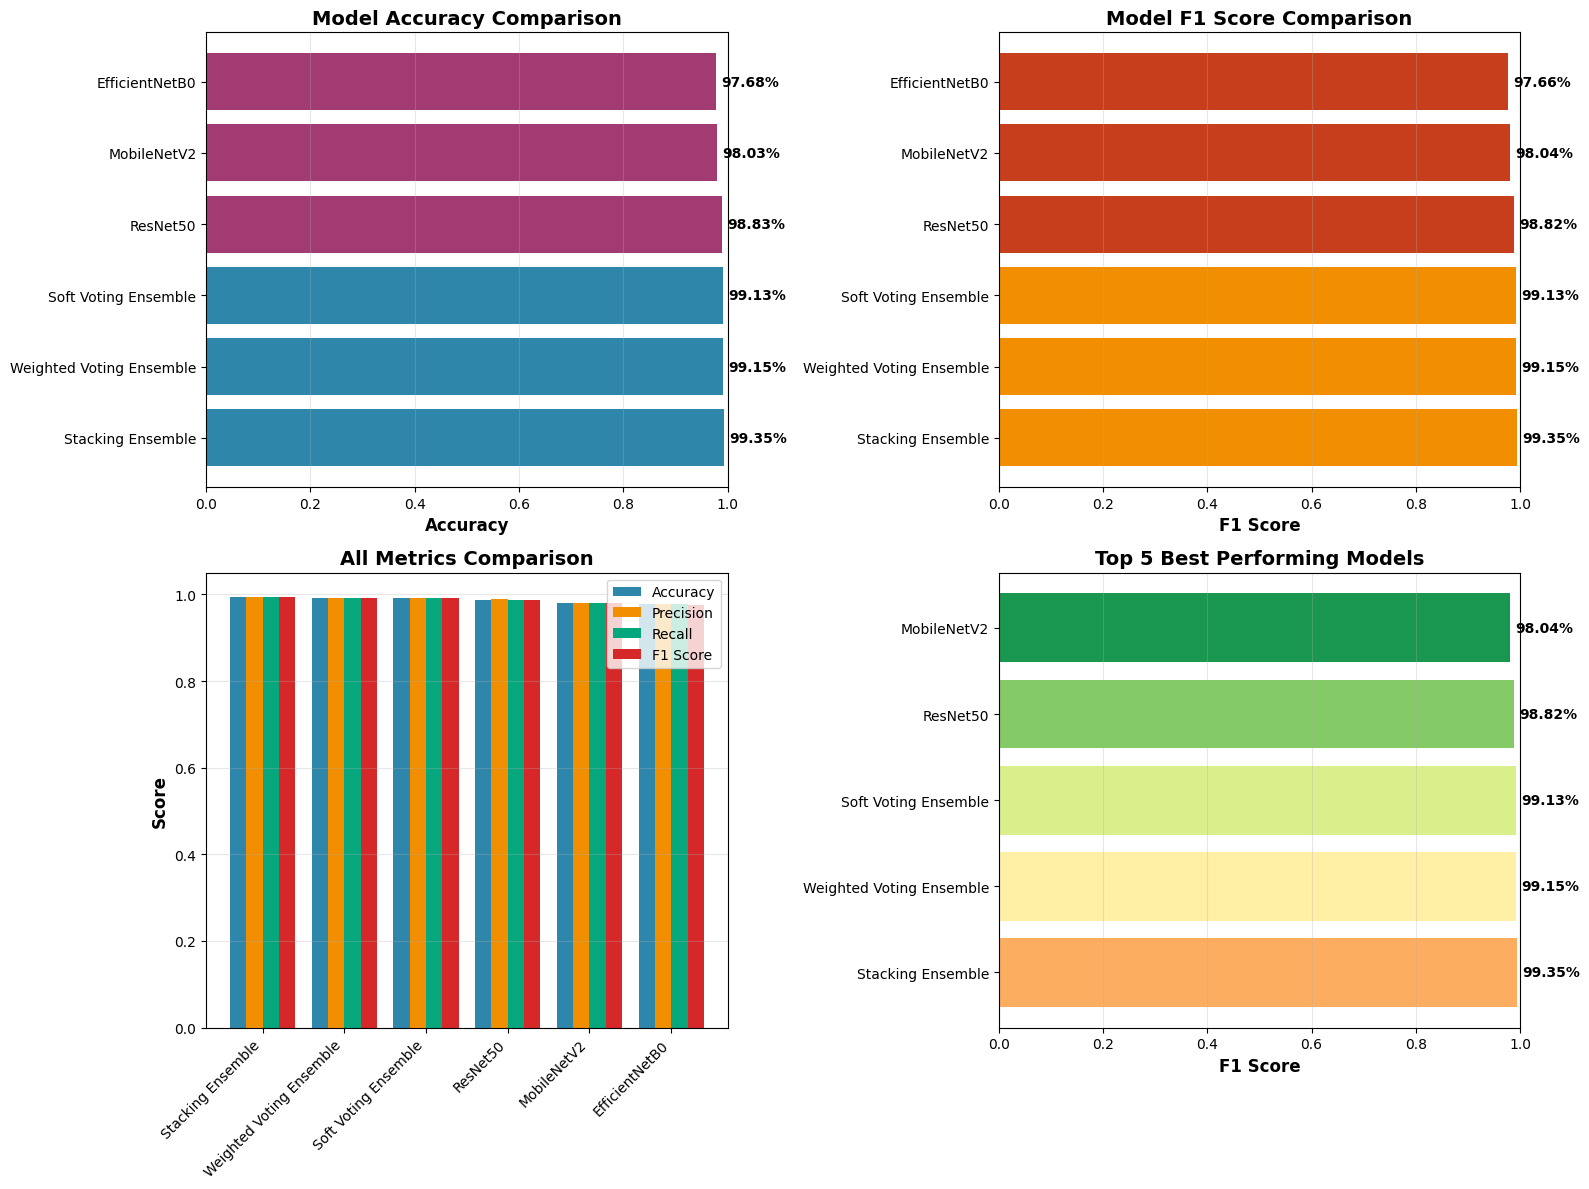

Visualisation saved as 'model_comparison.png'!


In [14]:
# BLOCK 15: Visualisation — Model Comparison
print("Creating Visualisations")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
 
models_list = df_comparison['Model'].tolist()
 
# 1. Accuracy comparison
ax1 = axes[0, 0]
colors_acc = ['#2E86AB' if i < 3 else '#A23B72' for i in range(len(models_list))]
ax1.barh(models_list, df_comparison['Accuracy'], color=colors_acc)
ax1.set_xlabel('Accuracy', fontweight='bold', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim([0, 1])
for i, v in enumerate(df_comparison['Accuracy']):
    ax1.text(v + 0.01, i, f'{v*100:.2f}%', va='center', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
 
# 2. F1 Score comparison
ax2 = axes[0, 1]
colors_f1 = ['#F18F01' if i < 3 else '#C73E1D' for i in range(len(models_list))]
ax2.barh(models_list, df_comparison['F1 Score'], color=colors_f1)
ax2.set_xlabel('F1 Score', fontweight='bold', fontsize=12)
ax2.set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim([0, 1])
for i, v in enumerate(df_comparison['F1 Score']):
    ax2.text(v + 0.01, i, f'{v*100:.2f}%', va='center', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
 
# 3. All metrics side by side
ax3 = axes[1, 0]
x     = np.arange(len(models_list))
width = 0.2
ax3.bar(x - width*1.5, df_comparison['Accuracy'],  width, label='Accuracy',  color='#2E86AB')
ax3.bar(x - width/2,   df_comparison['Precision'], width, label='Precision', color='#F18F01')
ax3.bar(x + width/2,   df_comparison['Recall'],    width, label='Recall',    color='#06A77D')
ax3.bar(x + width*1.5, df_comparison['F1 Score'],  width, label='F1 Score',  color='#D62828')
ax3.set_ylabel('Score', fontweight='bold', fontsize=12)
ax3.set_title('All Metrics Comparison', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(models_list, rotation=45, ha='right')
ax3.legend()
ax3.set_ylim([0, 1.05])
ax3.grid(axis='y', alpha=0.3)
 
# 4. Top-5 performers
ax4 = axes[1, 1]
top_5 = df_comparison.head(5)
ax4.barh(range(len(top_5)), top_5['F1 Score'],
         color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_5))))
ax4.set_yticks(range(len(top_5)))
ax4.set_yticklabels(top_5['Model'])
ax4.set_xlabel('F1 Score', fontweight='bold', fontsize=12)
ax4.set_title('Top 5 Best Performing Models', fontsize=14, fontweight='bold')
ax4.set_xlim([0, 1])
for i, v in enumerate(top_5['F1 Score']):
    ax4.text(v + 0.01, i, f'{v*100:.2f}%', va='center', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisation saved as 'model_comparison.png'!")

Training History Visualisation


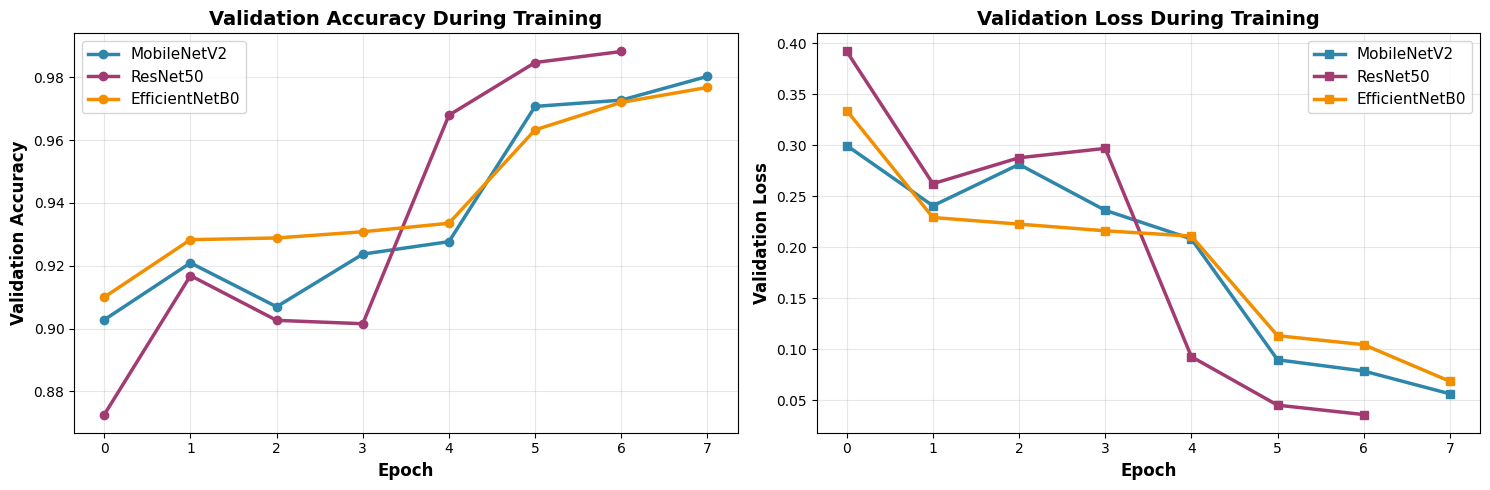

Training history visualisation saved as 'training_history.png'!


In [15]:
# BLOCK 16: Training History Visualisation
print("Training History Visualisation")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = ['#2E86AB', '#A23B72', '#F18F01']
 
for name, color in zip(model_names, colors):
    history = histories_dict[name]
    axes[0].plot(history['val_accuracy'], marker='o', linewidth=2.5, label=name, color=color)
    axes[1].plot(history['val_loss'],     marker='s', linewidth=2.5, label=name, color=color)
 
axes[0].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Validation Accuracy', fontweight='bold', fontsize=12)
axes[0].set_title('Validation Accuracy During Training', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
 
axes[1].set_xlabel('Epoch', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Validation Loss', fontweight='bold', fontsize=12)
axes[1].set_title('Validation Loss During Training', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history visualisation saved as 'training_history.png'!")
 

In [16]:
# BLOCK 17: Save Models
print("Saving Models")
# PyTorch convention: save state_dict (weights only) as .pth
# To reload: model = build_model(name, num_classes); model.load_state_dict(torch.load(f'{name}_model.pth'))
for name, model in models_dict.items():
    save_path = f'{name}_model.pth'
    torch.save(model.state_dict(), save_path)
    print(f"Saved {save_path}")
 
# Save meta-learner for stacking ensemble
with open('meta_learner.pkl', 'wb') as f:
    pickle.dump(meta_model, f)
print("Saved meta_learner.pkl")
 
print("\nAll done!")

Saving Models
Saved MobileNetV2_model.pth
Saved ResNet50_model.pth
Saved EfficientNetB0_model.pth
Saved meta_learner.pkl

All done!
